In [1]:
# import dependencies
%matplotlib inline
import os
import sys
import spatioev as se
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scimap
import scimap as sm

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

In [3]:
adata = se.load_h5ad("data/exp_2/34434_1_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 1766481 × 37
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractual_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11b_nuclear', 'CD19_nuclear', 'CD20_nuclear', 'CD27_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD38_nuclear', 'CD4_nuclear', 'CD4_2_nuclear', 'CD56_nuclear', 'CD8_nuclear', 'CD8_2_nuclear', 'CK19_nuclear', 'COL3_nuclear', 'CXCL13_nuclear', 'CXCR5_nuclear', 'DNA_1_nuclear', 'FAP_nuclear', 'FOXP3_nuclear', 'FOXP3_2_nuclear', 'GATA3_nuclear', 'GranzymeB_nuclear', 'HLADR_nuclear', 'IgA_nuclear', 'IgM_nuclear', 'Ki67_nuclear', 'MERTK_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDGFRa_nuclear', 'PDL1

In [4]:
# 1) Read annotations CSV (saved from adata_final.obs.to_csv, so index is first column)
ann = pd.read_csv("data/exp_2/34434_1_annotation.csv", index_col=0)

# 2) Optional: keep only columns you want
ann = ann[["Tier_A", "Tier_B"]]

# 3) Join into adata.obs by cell ID (index)
adata.obs = adata.obs.join(ann, how="left")

In [5]:
adata.obs["Tier_A"].value_counts()

Tier_A
Fibroblasts                     447488
pancreatic ductal epithelium    423758
Vimentin only mesenchyme        285392
Endothelial cells               137447
pancreatic acinar epithelium    124722
T cells                         106306
Muscularis externa               64475
B lineage                        60907
Vascular smooth muscle           45169
Duodenum epithelial              19284
noise                            18725
Nerves                            9980
Islets                            9202
Necrotic tumor                    7826
Muscularis mucosa                 5749
Unknown                             51
Name: count, dtype: int64

In [6]:
# read in pixel features
pix = pd.read_csv("data/exp_2/pixel_features.csv", index_col=0)
pix.head()

# join pixel features into adata.obs by label and fov
adata.obs = adata.obs.merge(pix, 
                            on=["label", "fov"],
                            how="left")

In [7]:
# Remove cells with NaN in pixel feature columns
pix_cols = pix.columns.tolist()
mask = adata.obs[pix_cols].notna().all(axis=1)
print(f"Keeping {mask.sum()} / {len(mask)} cells after removing NaN rows")
adata = adata[mask].copy()

Keeping 1763634 / 1766481 cells after removing NaN rows


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



### Ripley’s K by phenotype — global clustering

ripleys_k_by_phenotype(...) asks, for one phenotype at one radius: 

are cells of this phenotype more spatially clustered than expected under complete spatial randomness 
within the image window? 

In [7]:
ripley_df = se.spatial.ripleys_k_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    radius=50/0.325,   # or whatever spatial scale you want to test
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
)
ripley_df.head()

,imageid,phenotype,radius,K_observed,K_expected,L,L_minus_r
0,34434_1,pancreatic acinar epithelium,153.846154,6.054685e+05,74357.22257,439.006381,285.160227
1,34434_1,Vimentin only mesenchyme,153.846154,1.746541e+05,74357.22257,235.784099,81.937945
2,34434_1,Vascular smooth muscle,153.846154,2.089478e+06,74357.22257,815.537469,661.691315
3,34434_1,Endothelial cells,153.846154,2.204705e+05,74357.22257,264.911189,111.065035
4,34434_1,T cells,153.846154,4.500074e+05,74357.22257,378.473005,224.626852


when you run ripleys_k_by_phenotype(...) over a series of radii, you ask:

at what spatial scales is this phenotype clustered, random-like, or dispersed?

In [8]:
radii = [20/0.325, 50/0.325, 100/0.325, 150/0.325, 200/0.325]

ripley_all = []
for r in radii:
    df = se.spatial.ripleys_k_by_phenotype(
        adata,
        phenotype_key="Tier_A",
        radius=r,
        x_key="X_centroid",
        y_key="Y_centroid",
        image_key="imageid",
    )
    ripley_all.append(df)

ripley_all = pd.concat(ripley_all, ignore_index=True)

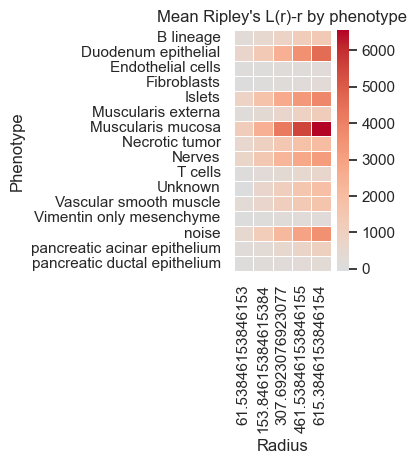

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_df = (
    ripley_all
    .groupby(["phenotype", "radius"], observed=False)["L_minus_r"]
    .mean()
    .unstack()
)

plt.figure(figsize=(4, max(4, 0.3 * heat_df.shape[0])))
sns.heatmap(
    heat_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Mean Ripley's L(r)-r by phenotype")
plt.xlabel("Radius")
plt.ylabel("Phenotype")
plt.tight_layout()
plt.show()


How to read scale biologically
A phenotype can behave differently at different scales:

positive at small radius only
tight local clusters
Example: small lymphocyte aggregates, compact endothelial neighborhoods

positive at both small and large radii
clustering persists across scales
Example: large stromal territories or broad tumour-rich regions

negative at small radius, positive at larger radius
local spacing but broader regional aggregation
Example: cells avoid sitting directly on top of each other but still occupy the same larger compartment

near zero everywhere
little obvious spatial structure for that phenotype

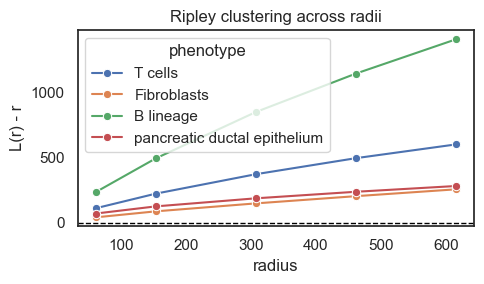

In [10]:
selected = [
    "pancreatic ductal epithelium",
    "Fibroblasts",
    "T cells",
    "B lineage",
]

plot_df = ripley_all[ripley_all["phenotype"].isin(selected)].copy()

plt.figure(figsize=(5, 3))
sns.lineplot(
    data=plot_df,
    x="radius",
    y="L_minus_r",
    hue="phenotype",
    marker="o",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("L(r) - r")
plt.title("Ripley clustering across radii")
plt.grid(False)
plt.tight_layout()
plt.show()


identify locally clustered cells of interest

In [11]:
local_df = se.spatial.ripley_local_counts_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    radius=50,
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    add_to_obs=True,
)
local_df

,cell_id,imageid,phenotype,radius,same_type_neighbor_count,expected_same_type_neighbor_count,same_type_neighbor_excess,same_type_neighbor_ratio,is_ripley_hotspot
0,34434_1_0,34434_1,pancreatic acinar epithelium,50,0.0,0.359987,-0.359987,0.0,False
1,34434_1_4,34434_1,pancreatic acinar epithelium,50,0.0,0.359987,-0.359987,0.0,False
2,34434_1_11704,34434_1,pancreatic acinar epithelium,50,0.0,0.359987,-0.359987,0.0,False
3,34434_1_22272,34434_1,pancreatic acinar epithelium,50,0.0,0.359987,-0.359987,0.0,False
4,34434_1_22726,34434_1,pancreatic acinar epithelium,50,0.0,0.359987,-0.359987,0.0,False
...,...,...,...,...,...,...,...,...,...
1766476,34434_1_1540151,34434_1,Unknown,50,0.0,0.000147,-0.000147,0.0,False
1766477,34434_1_1557505,34434_1,Unknown,50,0.0,0.000147,-0.000147,0.0,False
1766478,34434_1_1571530,34434_1,Unknown,50,0.0,0.000147,-0.000147,0.0,False
1766479,34434_1_1573958,34434_1,Unknown,50,0.0,0.000147,-0.000147,0.0,False


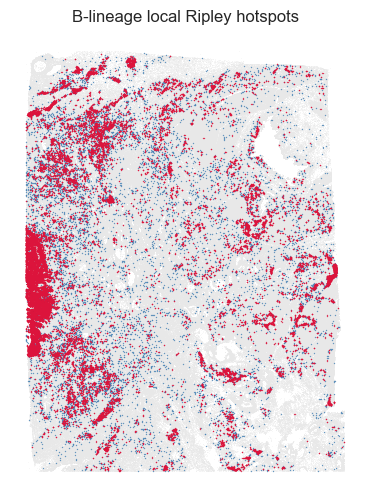

In [14]:
hotspot_col = "ripley_local_hotspot__Tier_A__r50"

import matplotlib.pyplot as plt
import seaborn as sns

source_mask = adata.obs["Tier_A"] == "B lineage"
hot_mask = source_mask & adata.obs["ripley_local_hotspot__Tier_A__r50"].fillna(False)

fig, ax = plt.subplots(figsize=(6, 6))

# all cells in gray
sns.scatterplot(
    data=adata.obs,
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=0.3,
    alpha=0.3,
    linewidth=0,
    ax=ax,
)

# non-hotspot B-lineage cells
sns.scatterplot(
    data=adata.obs[source_mask & ~hot_mask],
    x="X_centroid",
    y="Y_centroid",
    color="steelblue",
    s=1,
    alpha=0.8,
    linewidth=0,
    ax=ax,
)

# hotspot B-lineage cells
sns.scatterplot(
    data=adata.obs[hot_mask],
    x="X_centroid",
    y="Y_centroid",
    color="crimson",
    s=1,
    alpha=0.8,
    linewidth=0,
    ax=ax,
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("B-lineage local Ripley hotspots")
plt.show()


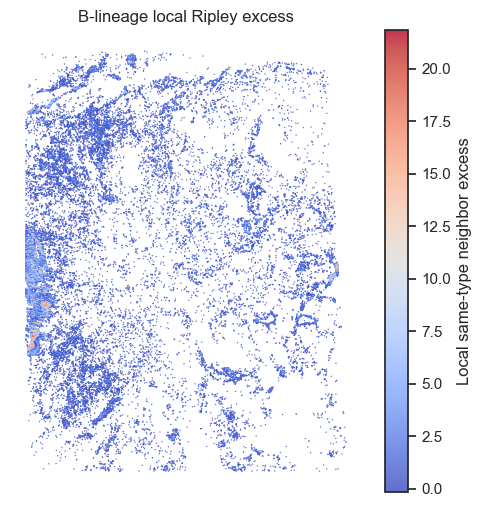

In [17]:
score_col = "ripley_local_excess__Tier_A__r50"

b_df = adata.obs[adata.obs["Tier_A"] == "B lineage"].copy()

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(
    b_df["X_centroid"],
    b_df["Y_centroid"],
    c=b_df["ripley_local_excess__Tier_A__r50"],
    cmap="coolwarm",
    s=1,
    alpha=0.8,
    linewidths=0,
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.colorbar(sc, ax=ax, label="Local same-type neighbor excess")
plt.title("B-lineage local Ripley excess")
plt.show()



### Cross phenotype Ripley’s K

between a pair of phenotypes

In [32]:
df = se.spatial.cross_ripleys_k_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="Fibroblasts",
    radius=20/0.325
)
df

,imageid,source,target,radius,K_observed,K_expected,L,L_minus_r,mean_target_neighbors_per_source,expected_target_neighbors_per_source,source_neighbor_excess,source_neighbor_ratio,fraction_source_with_target_neighbor,directional_observed,directional_expected,directional_excess,directional_ratio
0,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,6147.588057,11897.155611,44.236162,-17.302299,1.010973,1.956492,-0.945519,0.516728,0.398053,1.010973,1.956492,-0.945519,0.516728


overall, across the whole image, pancreatic ductal epithelium and fibroblasts have fewer close pairs than expected at about 20 um

fibroblasts are often stromal/periglandular rather than directly intermingled with epithelial cells

there is a gap at very short range

In [28]:
radii = np.linspace(10,800,30)

curve = se.spatial.cross_ripleys_curve_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="Fibroblasts",
    radii=radii
)

curve.head()

,radius,K,L,L_minus_r,imageid,source,target
0,10.000000,0.186548,0.243680,-9.756320,34434_1,pancreatic ductal epithelium,Fibroblasts
1,37.241379,1450.353104,21.486315,-15.755064,34434_1,pancreatic ductal epithelium,Fibroblasts
2,64.482759,6981.931048,47.142525,-17.340233,34434_1,pancreatic ductal epithelium,Fibroblasts
3,91.724138,17496.736340,74.628307,-17.095831,34434_1,pancreatic ductal epithelium,Fibroblasts
4,118.965517,33075.142458,102.606748,-16.358769,34434_1,pancreatic ductal epithelium,Fibroblasts


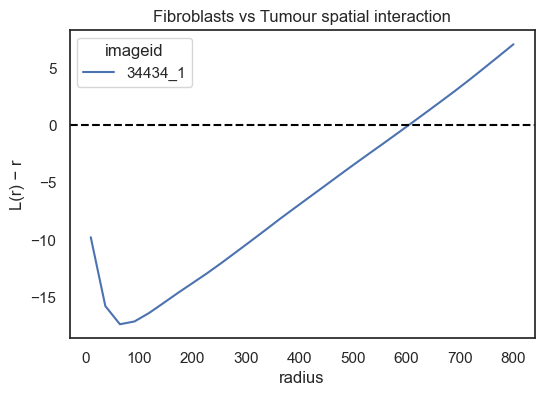

In [29]:
plt.figure(figsize=(6,4))

sns.lineplot(
    data=curve,
    x="radius",
    y="L_minus_r",
    hue="imageid"
)

plt.axhline(0,color="black",linestyle="--")

plt.ylabel("L(r) − r")
plt.title("Fibroblasts vs Tumour spatial interaction")

plt.show()

In [30]:
cross_local_df = se.spatial.cross_ripley_local_counts(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="Fibroblasts",
    radius=20/0.325,
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    add_to_obs=True,
)
cross_local_df

,cell_id,imageid,source,target,radius,target_neighbor_count,expected_target_neighbor_count,target_neighbor_excess,target_neighbor_ratio,is_cross_ripley_hotspot
0,34434_1_486,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,1.0,1.956492,-0.956492,0.511119,False
1,34434_1_661,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,0.0,1.956492,-1.956492,0.000000,False
2,34434_1_673,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,0.0,1.956492,-1.956492,0.000000,False
3,34434_1_683,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,0.0,1.956492,-1.956492,0.000000,False
4,34434_1_731,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,0.0,1.956492,-1.956492,0.000000,False
...,...,...,...,...,...,...,...,...,...,...
423753,34434_1_1766202,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,0.0,1.956492,-1.956492,0.000000,False
423754,34434_1_1766234,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,1.0,1.956492,-0.956492,0.511119,False
423755,34434_1_1766241,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,0.0,1.956492,-1.956492,0.000000,False
423756,34434_1_1766253,34434_1,pancreatic ductal epithelium,Fibroblasts,61.538462,0.0,1.956492,-1.956492,0.000000,False


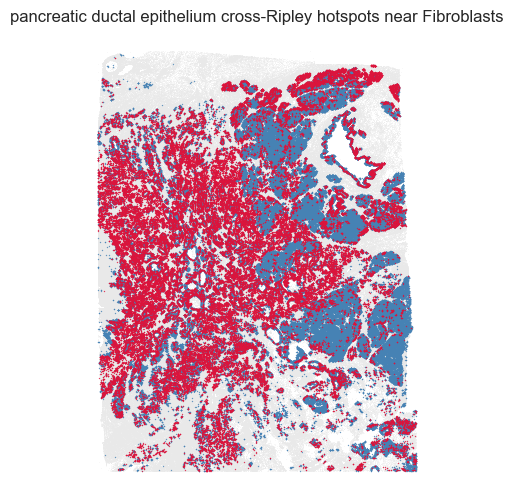

In [35]:
hotspot_col = "cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__r61.53846153846153__hotspot"

import matplotlib.pyplot as plt
import seaborn as sns

source_mask = adata.obs["Tier_A"] == "pancreatic ductal epithelium"
hot_mask = adata.obs[hotspot_col].fillna(False)
gray_mask = ~hot_mask

fig, ax = plt.subplots(figsize=(6, 6))

# background cells in gray
sns.scatterplot(
    data=adata.obs[gray_mask],
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=0.3,
    alpha=0.4,
    linewidth=0,
    ax=ax,
)

sns.scatterplot(
    data=adata.obs[source_mask & ~hot_mask],
    x="X_centroid",
    y="Y_centroid",
    color="steelblue",
    s=1,
    alpha=0.8,
    linewidth=0,
    ax=ax,
)

# hotspot T cells in red
sns.scatterplot(
    data=adata.obs[hot_mask],
    x="X_centroid",
    y="Y_centroid",
    color="crimson",
    s=1,
    alpha=0.8,
    linewidth=0,
    ax=ax,
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("pancreatic ductal epithelium cross-Ripley hotspots near Fibroblasts")
plt.show()


In [ ]:
count_col = "cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__r61.53846153846153__count"
ratio_col = "cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__r61.53846153846153__ratio"

strict_hot_mask = (
    (adata.obs["Tier_A"] == "pancreatic ductal epithelium") &
    (adata.obs[count_col].fillna(0) >= 3) &
    (adata.obs[ratio_col].fillna(0) > 2)
)


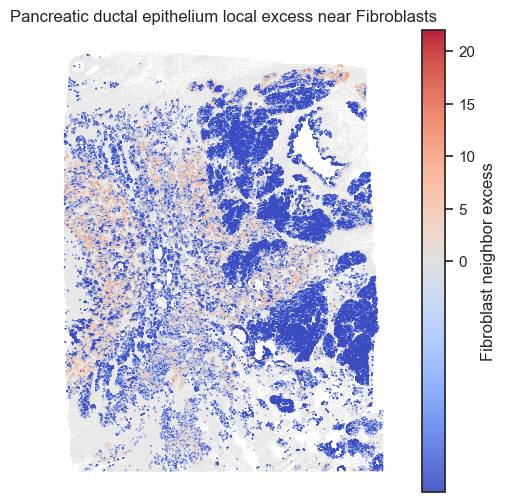

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

source_mask = adata.obs["Tier_A"] == "pancreatic ductal epithelium"
excess_col = "cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__r61.53846153846153__excess"

from matplotlib.colors import TwoSlopeNorm

vals = adata.obs.loc[source_mask, excess_col]
norm = TwoSlopeNorm(vmin=vals.min(), vcenter=0, vmax=vals.max())


fig, ax = plt.subplots(figsize=(6, 6))

# all non-source cells in gray
sns.scatterplot(
    data=adata.obs[~source_mask],
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=0.3,
    alpha=0.3,
    linewidth=0,
    ax=ax,
)

# source cells colored by local excess
sc = ax.scatter(
    adata.obs.loc[source_mask, "X_centroid"],
    adata.obs.loc[source_mask, "Y_centroid"],
    c=adata.obs.loc[source_mask, excess_col],
    cmap="coolwarm",
    s=1,
    alpha=0.9,
    linewidths=0,
    norm=norm,
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Fibroblast neighbor excess")

plt.title("Pancreatic ductal epithelium local excess near Fibroblasts")
plt.show()


In [ ]:
import numpy as np

radii = np.array([20/0.325, 50/0.325, 100/0.325, 150/0.325, 200/0.325])

env_df = se.spatial.cross_ripley_envelope_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="T cells",
    radii=radii,
    n_sim=99,
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
)

env_df.head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))

plt.plot(env_df["radius"], env_df["L_minus_r"], color="crimson", linewidth=1.5, label="Observed")
plt.fill_between(
    env_df["radius"],
    env_df["envelope_low"],
    env_df["envelope_high"],
    color="lightgray",
    alpha=0.6,
    label="95% envelope",
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Radius")
plt.ylabel("L(r) - r")
plt.title("Cross-Ripley envelope\nDuctal epithelium vs T cells")
plt.legend(frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
perm_df = se.spatial.cross_ripley_permutation_envelope(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="T cells",
    radii=radii,
    n_sim=199,
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    random_state=42,
)

perm_df.head()

In [ ]:
plt.figure(figsize=(4, 3))

plt.plot(perm_df["radius"], perm_df["L_minus_r"], color="navy", linewidth=1.5, label="Observed")
plt.fill_between(
    perm_df["radius"],
    perm_df["envelope_low"],
    perm_df["envelope_high"],
    color="lightblue",
    alpha=0.5,
    label="95% permutation envelope",
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Radius")
plt.ylabel("L(r) - r")
plt.title("Cross-Ripley permutation envelope\nDuctal epithelium vs T cells")
plt.legend(frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()


all pairs

In [26]:
cross_df = se.spatial.cross_ripleys_k_all_pairs(
    adata,
    phenotype_key="Tier_A",
    radius=30/0.325,
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    include_self_pairs=False,
)

cross_df.head()


,imageid,source,target,radius,K_observed,K_expected,L,L_minus_r,mean_target_neighbors_per_source,expected_target_neighbors_per_source,source_neighbor_excess,source_neighbor_ratio,fraction_source_with_target_neighbor,directional_observed,directional_expected,directional_excess,directional_ratio
0,34434_1,pancreatic acinar epithelium,Vimentin only mesenchyme,92.307692,28303.202690,26768.600125,94.916749,2.609057,2.968458,2.807508,0.160950,1.057328,0.702835,2.968458,2.807508,0.160950,1.057328
1,34434_1,pancreatic acinar epithelium,Vascular smooth muscle,92.307692,8383.736327,26768.600125,51.658747,-40.648945,0.139166,0.444344,-0.305179,0.313193,0.068705,0.139166,0.444344,-0.305179,0.313193
2,34434_1,pancreatic acinar epithelium,Endothelial cells,92.307692,46243.943069,26768.600125,121.325613,29.017920,2.335843,1.352118,0.983725,1.727544,0.759120,2.335843,1.352118,0.983725,1.727544
3,34434_1,pancreatic acinar epithelium,T cells,92.307692,20617.018028,26768.600125,81.009880,-11.297812,0.805447,1.045772,-0.240325,0.770194,0.341399,0.805447,1.045772,-0.240325,0.770194
4,34434_1,pancreatic acinar epithelium,Fibroblasts,92.307692,6405.084173,26768.600125,45.153091,-47.154601,1.053319,4.402107,-3.348788,0.239276,0.363128,1.053319,4.402107,-3.348788,0.239276


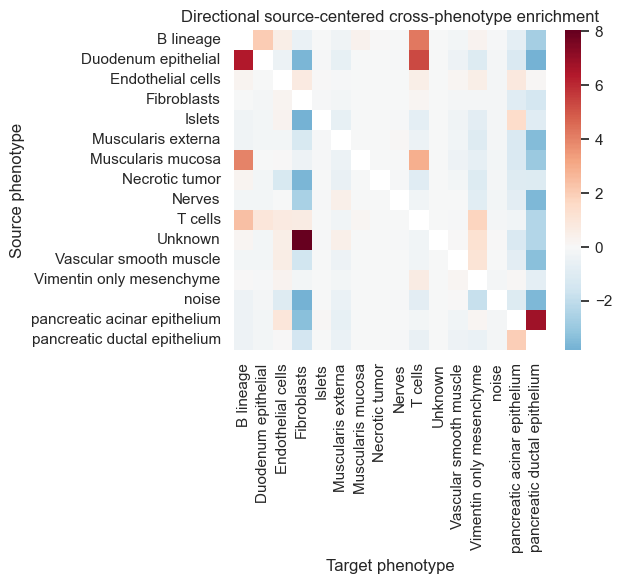

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_df = (
    cross_df.groupby(["source", "target"], observed=False)["source_neighbor_excess"]
    .mean()
    .unstack()
)

plt.figure(figsize=(6.5, 6))
sns.heatmap(heat_df, cmap="RdBu_r", center=0)
plt.title("Directional source-centered cross-phenotype enrichment")
plt.xlabel("Target phenotype")
plt.ylabel("Source phenotype")
plt.tight_layout()
plt.show()


The Moran side of spatial_stats.py covers three layers of questions: 

global spatial autocorrelation of one feature \
global spatial association between two features \
local hotspot / co-localization maps 

### Single-feature Moran’s I

computes global Moran’s I from coordinates plus one numeric value per cell \

What biological question it answers: \
do similar values cluster spatially?

Examples: 

are high nc_ratio cells spatially grouped? \
is polarity_score spatially patchy? \
are high PDL1 cells forming regional hotspots?

In [ ]:
adata = se.add_obs_from_var(adata, markers=["FAP"], zscore=True)

In [7]:
adata_fib = adata[adata.obs["Tier_A"] == "Fibroblasts"].copy()

In [8]:
print("FAP_expr_z in obs:", "FAP_expr_z" in adata_fib.obs.columns)
print("n fibroblast cells:", adata_fib.n_obs)
print("finite FAP:", np.isfinite(adata_fib.obs["FAP_expr_z"]).sum())
print("FAP std:", np.nanstd(adata_fib.obs["FAP_expr_z"]))
print("finite X:", np.isfinite(adata_fib.obs["X_centroid"]).sum())
print("finite Y:", np.isfinite(adata_fib.obs["Y_centroid"]).sum())


FAP_expr_z in obs: True
n fibroblast cells: 447488
finite FAP: 447488
FAP std: 0.8097581870950904
finite X: 447488
finite Y: 447488


In [9]:
fap_moran = se.spatial.morans_i_by_image(
    adata_fib,
    value_key="FAP_expr_z",
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    k=8,
)
fap_moran

,imageid,morans_i
0,34434_1,0.815686


Interpretation:

I > 0: similar values cluster together \
I ~ 0: random spatial arrangement \
I < 0: neighboring cells tend to have dissimilar values

In [ ]:
fap_moran_perm = se.spatial.morans_i_by_image_permutation_test(
    adata_fib,
    value_key="FAP_expr_z",
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    k=8,
    n_sim=999,
    random_state=42,
)
fap_moran_perm

### Local Moran’s I

What it does:

computes a per-cell local Moran score

What biological question it answers:

where are the local hotspots or coldspots?


In [10]:
adata_fib = se.spatial.add_local_morans_i(
    adata_fib,
    value_key="FAP_expr_z",
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    k=8,
)

In [11]:
adata_fib = se.spatial.add_local_morans_i_quadrants(
    adata_fib,
    value_key="FAP_expr_z",
)

will add adata_fib.obs["local_morans_quadrant__FAP_expr_z"] 

with labels:

high-high \
low-low \
high-low \
low-high \
unclassified

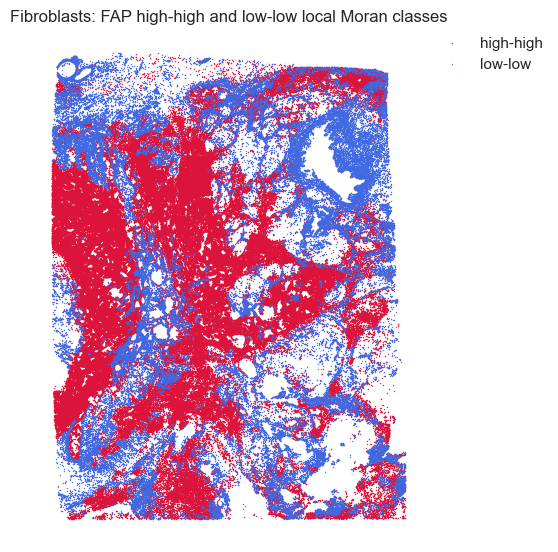

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

quad_col = "local_morans_quadrant__FAP_expr_z"

hh_mask = adata_fib.obs[quad_col] == "high-high"
ll_mask = adata_fib.obs[quad_col] == "low-low"
other_mask = ~(hh_mask | ll_mask)

fig, ax = plt.subplots(figsize=(6, 6))

# other fibroblasts in gray
sns.scatterplot(
    data=adata_fib.obs[other_mask],
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=1,
    alpha=0.4,
    linewidth=0,
    ax=ax,
)

# high-high hotspots
sns.scatterplot(
    data=adata_fib.obs[hh_mask],
    x="X_centroid",
    y="Y_centroid",
    color="crimson",
    s=1,
    alpha=0.9,
    linewidth=0,
    ax=ax,
    label="high-high",
)

# low-low coldspots
sns.scatterplot(
    data=adata_fib.obs[ll_mask],
    x="X_centroid",
    y="Y_centroid",
    color="royalblue",
    s=1,
    alpha=0.9,
    linewidth=0,
    ax=ax,
    label="low-low",
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.title("Fibroblasts: FAP high-high and low-low local Moran classes")
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


### Cross Moran's I

What it does: \
computes spatial association between two continuous features 

What biological question it answers: \
where high values of one feature occur, do neighboring cells also tend to have high values of another feature?

Examples:

is tumour-cell polarity_score spatially associated with neighboring fibroblast FAP? \
is local tumour density associated with surrounding collagen alignment? \
are high PDL1 regions near high macrophage markers? 

In [8]:
adata = se.add_obs_from_var(
    adata,
    markers=["FAP", "aSMA", "PDPN", "Thy1", "Ki67", "CK19", "NaKATPase"],
    zscore=True,
)

In [9]:
adata = se.add_zscore_obs_features(
    adata,
    feature_keys=["nc_ratio", "polarity_score", "entropy", "inertia"],
)

In [10]:
pair_df = se.spatial.cross_morans_i_feature_matrix(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="Fibroblasts",
    target_phenotype="pancreatic ductal epithelium",
    source_feature_keys=["FAP_expr_z"],
    target_feature_keys=["Ki67_expr_z"],
    radius=50/0.325,
    agg="mean",
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    k=8,
)

pair_df

,imageid,source_phenotype,target_phenotype,source_feature,target_feature,target_summary_feature,cross_morans_i,n_source_cells,n_nonmissing_pairs
0,34434_1,Fibroblasts,pancreatic ductal epithelium,FAP_expr_z,Ki67_expr_z,neighbor_mean__Ki67_expr_z,-0.012759,447469,330366


In [11]:
matrix_df = se.spatial.cross_morans_i_feature_matrix(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="Fibroblasts",
    target_phenotype="pancreatic ductal epithelium",
    source_feature_keys=["FAP_expr_z", "aSMA_expr_z", "PDPN_expr_z", "Thy1_expr_z"],
    target_feature_keys=["Ki67_expr_z", "CK19_expr_z", "NaKATPase_expr_z", "nc_ratio_z", "polarity_score_z", "entropy_z", "inertia_z"],
    radius=50/0.325,
    agg="mean",
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    k=8,
)

matrix_df.head()

,imageid,source_phenotype,target_phenotype,source_feature,target_feature,target_summary_feature,cross_morans_i,n_source_cells,n_nonmissing_pairs
0,34434_1,Fibroblasts,pancreatic ductal epithelium,FAP_expr_z,Ki67_expr_z,neighbor_mean__Ki67_expr_z,-0.012759,447469,330366
1,34434_1,Fibroblasts,pancreatic ductal epithelium,FAP_expr_z,CK19_expr_z,neighbor_mean__CK19_expr_z,0.195456,447469,330366
2,34434_1,Fibroblasts,pancreatic ductal epithelium,FAP_expr_z,NaKATPase_expr_z,neighbor_mean__NaKATPase_expr_z,-0.252016,447469,330366
3,34434_1,Fibroblasts,pancreatic ductal epithelium,FAP_expr_z,nc_ratio_z,neighbor_mean__nc_ratio_z,-0.118630,447469,330366
4,34434_1,Fibroblasts,pancreatic ductal epithelium,FAP_expr_z,polarity_score_z,neighbor_mean__polarity_score_z,-0.056406,447469,330366


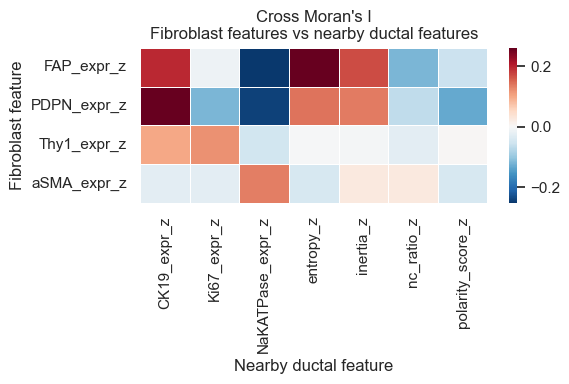

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_df = matrix_df.pivot(
    index="source_feature",
    columns="target_feature",
    values="cross_morans_i"
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    heat_df,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
)
plt.title("Cross Moran's I\nFibroblast features vs nearby ductal features")
plt.xlabel("Nearby ductal feature")
plt.ylabel("Fibroblast feature")
plt.tight_layout()
plt.show()


In [13]:
adata_duct_local = se.spatial.add_local_cross_morans_i_between_phenotypes(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="Fibroblasts",
    source_feature_key="entropy_z",
    target_feature_key="FAP_expr_z",
    radius=50/0.325,
    agg="mean",
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    k=8,
)

In [14]:
adata_duct_local = se.spatial.add_local_cross_morans_i_quadrants(
    adata_duct_local,
    source_value_key="entropy_z",
    target_neighbor_value_key="neighbor_mean__FAP_expr_z",
    local_i_key="local_cross_morans_i__entropy_z__pancreatic ductal epithelium__vs__Fibroblasts__neighbor_mean__FAP_expr_z",
)

In [16]:
quad_col = "local_cross_morans_quadrant__entropy_z__neighbor_mean__FAP_expr_z"

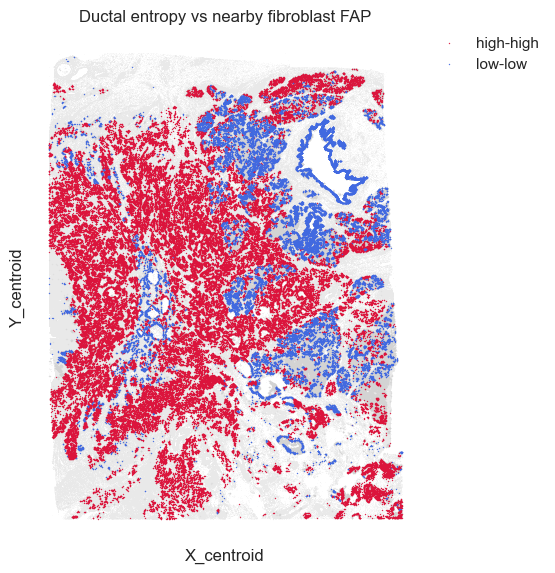

In [17]:
hh_mask = adata_duct_local.obs[quad_col] == "high-high"
ll_mask = adata_duct_local.obs[quad_col] == "low-low"
other_mask = ~(hh_mask | ll_mask)

fig, ax = plt.subplots(figsize=(6, 6))

sns.scatterplot(
    data=adata.obs,
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=0.3,
    alpha=0.2,
    linewidth=0,
    ax=ax,
)

sns.scatterplot(
    data=adata_duct_local.obs[other_mask],
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=1,
    alpha=0.4,
    linewidth=0,
    ax=ax,
)

sns.scatterplot(
    data=adata_duct_local.obs[hh_mask],
    x="X_centroid",
    y="Y_centroid",
    color="crimson",
    s=1,
    alpha=0.9,
    linewidth=0,
    ax=ax,
    label="high-high",
)

sns.scatterplot(
    data=adata_duct_local.obs[ll_mask],
    x="X_centroid",
    y="Y_centroid",
    color="royalblue",
    s=1,
    alpha=0.9,
    linewidth=0,
    ax=ax,
    label="low-low",
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.title("Ductal entropy vs nearby fibroblast FAP")
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


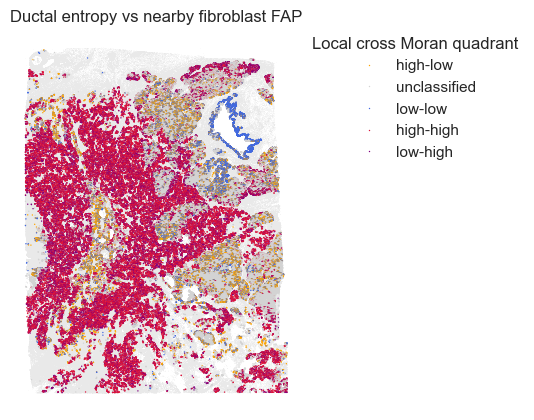

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

quad_col = "local_cross_morans_quadrant__entropy_z__neighbor_mean__FAP_expr_z"

palette = {
    "high-high": "crimson",
    "low-low": "royalblue",
    "high-low": "orange",
    "low-high": "purple",
    "unclassified": "lightgray",
}

fig, ax = plt.subplots(figsize=(6, 6))

# all non-ductal cells in gray background
sns.scatterplot(
    data=adata.obs[adata.obs["Tier_A"] != "pancreatic ductal epithelium"],
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=0.3,
    alpha=0.2,
    linewidth=0,
    ax=ax,
)

# ductal cells colored by local cross-Moran quadrant
sns.scatterplot(
    data=adata_duct_local.obs,
    x="X_centroid",
    y="Y_centroid",
    hue=quad_col,
    palette=palette,
    s=1,
    linewidth=0,
    ax=ax,
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(
    title="Local cross Moran quadrant",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.title("Ductal entropy vs nearby fibroblast FAP")
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()
